This notebook is for random forest with default hyperpameters for tuning (the n_estimators is fixed for 700 and max_features different values are tested). The pr-auc for validation did not pass the tuned model.

  ## 1. Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.base import clone


from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")




In [2]:
df = pd.read_csv("new_df.csv")

target_col = "chagas"

X = df.drop(columns=[target_col])
y = df[target_col]
groups = df["patient_id"]

print("Dataset size:", df.shape)

print("\nTarget variable distribution:")
print(y.value_counts())

print("\nTarget proportions:")
print(y.value_counts(normalize=True))




Dataset size: (342142, 42)

Target variable distribution:
chagas
0    335583
1      6559
Name: count, dtype: int64

Target proportions:
chagas
0    0.98083
1    0.01917
Name: proportion, dtype: float64


  ## 2. Train / Validation / Test Split by Patient

In [3]:
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_temp = X.iloc[temp_idx].copy()

y_train = y.iloc[train_idx].copy()
y_temp = y.iloc[temp_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_temp = groups.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=groups_temp)
)

X_val = X_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()

y_val = y_temp.iloc[val_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

groups_val = groups_temp.iloc[val_idx].copy()
groups_test = groups_temp.iloc[test_idx].copy()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)




Train: (239583, 41)
Validation: (51312, 41)
Test: (51247, 41)


  ## 3. Check Patient Overlap Between Splits

In [4]:
train_patients = set(groups_train)
val_patients = set(groups_val)
test_patients = set(groups_test)

train_val_overlap = train_patients & val_patients
train_test_overlap = train_patients & test_patients
val_test_overlap = val_patients & test_patients

print("Train-Val overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Val-Test overlap:", len(val_test_overlap))




Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


  ## 4. Data Preprocessing

In [5]:
drop_cols = [
    "exam_id",
    "patient_id",
    "interval_lead_idx",
    "n_usable_leads"
]

drop_cols = [
    col for col in drop_cols
    if col in X_train.columns
]

X_train = X_train.drop(columns=drop_cols)
X_val = X_val.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

for data_part in [X_train, X_val, X_test]:
    bool_cols = data_part.select_dtypes(include=["bool"]).columns
    data_part[bool_cols] = data_part[bool_cols].astype(int)

object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

if len(object_cols) > 0:
    X_train = X_train.drop(columns=object_cols)
    X_val = X_val.drop(columns=object_cols)
    X_test = X_test.drop(columns=object_cols)

print("MISSING VALUES BEFORE IMPUTATION")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

# Missingness indicators before imputation
missing_cols = X_train.columns[X_train.isna().any()].tolist()

for col in missing_cols:
    X_train[f"{col}_missing"] = X_train[col].isna().astype(int)
    X_val[f"{col}_missing"] = X_val[col].isna().astype(int)
    X_test[f"{col}_missing"] = X_test[col].isna().astype(int)

print("Missingness indicator features added:", len(missing_cols))

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("MISSING VALUES AFTER IMPUTATION")
print("Train:", X_train.isna().sum().sum())
print("Validation:", X_val.isna().sum().sum())
print("Test:", X_test.isna().sum().sum())

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")


MISSING VALUES BEFORE IMPUTATION
Train: 3200
Validation: 651
Test: 672
Missingness indicator features added: 11
MISSING VALUES AFTER IMPUTATION
Train: 0
Validation: 0
Test: 0

Features: 48
Training samples: 239583


  ## 5. Class Balance Check

In [6]:
print(f"Train positive rate: {y_train.mean():.4f} ({y_train.sum()}/{len(y_train)})")
print(f"Validation positive rate: {y_val.mean():.4f} ({y_val.sum()}/{len(y_val)})")
print(f"Test positive rate: {y_test.mean():.4f} ({y_test.sum()}/{len(y_test)})")



Train positive rate: 0.0186 (4450/239583)
Validation positive rate: 0.0218 (1120/51312)
Test positive rate: 0.0193 (989/51247)


  ## 6. Helper Function for F2 Threshold Selection

In [7]:
def get_best_f2_threshold(y_true, y_prob, beta=2):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    beta_squared = beta ** 2

    f2_scores = (
        (1 + beta_squared) * precision[:-1] * recall[:-1] /
        (beta_squared * precision[:-1] + recall[:-1] + 1e-9)
    )

    best_idx = np.argmax(f2_scores)

    return {
        "threshold": thresholds[best_idx],
        "f2": f2_scores[best_idx],
        "precision": precision[best_idx],
        "recall": recall[best_idx]
    }




  ## 7. Hyperparameter Tuning with Hold-Out Validation

In [8]:
param_grid = {
    "n_estimators": [700],
    "max_depth": [None],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": [0.3, 0.5, "sqrt"],
    "class_weight": ["balanced", "balanced_subsample"]
}

total_combinations = len(ParameterGrid(param_grid))
print("Total hyperparameter combinations:", total_combinations)



Total hyperparameter combinations: 6


In [9]:
results = []

best_score = -np.inf
best_model = None
best_params = None
best_threshold = None


for params in tqdm(ParameterGrid(param_grid), total=total_combinations, desc="Grid Search"):

    rf = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_val_prob = rf.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    y_val_pred_default = (y_val_prob >= 0.5).astype(int)

    val_balanced_acc_default = balanced_accuracy_score(
        y_val,
        y_val_pred_default
    )

    val_f1_default = f1_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    val_f2_default = fbeta_score(
        y_val,
        y_val_pred_default,
        beta=2,
        zero_division=0
    )

    val_precision_default = precision_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    val_recall_default = recall_score(
        y_val,
        y_val_pred_default,
        zero_division=0
    )

    threshold_info = get_best_f2_threshold(
        y_val,
        y_val_prob,
        beta=2
    )

    selected_threshold = threshold_info["threshold"]

    y_val_pred_selected = (
        y_val_prob >= selected_threshold
    ).astype(int)

    val_balanced_acc_selected = balanced_accuracy_score(
        y_val,
        y_val_pred_selected
    )

    val_f1_selected = f1_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    val_f2_selected = fbeta_score(
        y_val,
        y_val_pred_selected,
        beta=2,
        zero_division=0
    )

    val_precision_selected = precision_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    val_recall_selected = recall_score(
        y_val,
        y_val_pred_selected,
        zero_division=0
    )

    results.append({
        **params,
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,

        "threshold_f2": selected_threshold,

        "val_balanced_acc_default_0_5": val_balanced_acc_default,
        "val_f1_default_0_5": val_f1_default,
        "val_f2_default_0_5": val_f2_default,
        "val_precision_default_0_5": val_precision_default,
        "val_recall_default_0_5": val_recall_default,

        "val_balanced_acc_selected": val_balanced_acc_selected,
        "val_f1_selected": val_f1_selected,
        "val_f2_selected": val_f2_selected,
        "val_precision_selected": val_precision_selected,
        "val_recall_selected": val_recall_selected
    })

    if val_pr_auc > best_score:
        best_score = val_pr_auc
        best_model = rf
        best_params = params
        best_threshold = selected_threshold

results_df = (
    pd.DataFrame(results)
    .sort_values("val_pr_auc", ascending=False)
    .reset_index(drop=True)
)


print(f"Best PR-AUC score on validation set: {best_score:.4f}")

print("\nBest parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest threshold selected by validation F2: {best_threshold:.4f}")

print("\nTop 10 hyperparameter combinations by Validation PR-AUC:")

display_cols = (
    list(best_params.keys()) +
    [
        "val_roc_auc",
        "val_pr_auc",
        "threshold_f2",
        "val_balanced_acc_selected",
        "val_f1_selected",
        "val_f2_selected",
        "val_precision_selected",
        "val_recall_selected"
    ]
)

print(results_df[display_cols].head(10).to_string(index=False))




Grid Search: 100%|██████████| 6/6 [1:52:57<00:00, 1129.55s/it]  


Best PR-AUC score on validation set: 0.1323

Best parameters:
  class_weight: balanced_subsample
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 700

Best threshold selected by validation F2: 0.0500

Top 10 hyperparameter combinations by Validation PR-AUC:
      class_weight max_depth max_features  min_samples_leaf  min_samples_split  n_estimators  val_roc_auc  val_pr_auc  threshold_f2  val_balanced_acc_selected  val_f1_selected  val_f2_selected  val_precision_selected  val_recall_selected
balanced_subsample      None         sqrt                 1                  2           700     0.824458    0.132260      0.050000                   0.669139         0.192027         0.279093                0.126340             0.400000
          balanced      None         sqrt                 1                  2           700     0.822148    0.131557      0.044286                   0.681434         0.177261         0.276691                0.11086

  ## 8. Best Model Evaluation on Validation Set

In [10]:
y_val_prob_best = best_model.predict_proba(X_val)[:, 1]

y_val_pred_default = (y_val_prob_best >= 0.5).astype(int)
y_val_pred_selected = (y_val_prob_best >= best_threshold).astype(int)

val_roc_auc = roc_auc_score(y_val, y_val_prob_best)
val_pr_auc = average_precision_score(y_val, y_val_prob_best)

val_balanced_acc_default = balanced_accuracy_score(
    y_val,
    y_val_pred_default
)

val_f1_default = f1_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_f2_default = fbeta_score(
    y_val,
    y_val_pred_default,
    beta=2,
    zero_division=0
)

val_precision_default = precision_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_recall_default = recall_score(
    y_val,
    y_val_pred_default,
    zero_division=0
)

val_balanced_acc_selected = balanced_accuracy_score(
    y_val,
    y_val_pred_selected
)

val_f1_selected = f1_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

val_f2_selected = fbeta_score(
    y_val,
    y_val_pred_selected,
    beta=2,
    zero_division=0
)

val_precision_selected = precision_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

val_recall_selected = recall_score(
    y_val,
    y_val_pred_selected,
    zero_division=0
)

print(f"Selected threshold by validation F2: {best_threshold:.4f}")
print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC: {val_pr_auc:.4f}")

print("\nDefault threshold 0.5:")
print(f"Balanced Accuracy: {val_balanced_acc_default:.4f}")
print(f"F1-score: {val_f1_default:.4f}")
print(f"F2-score: {val_f2_default:.4f}")
print(f"Precision: {val_precision_default:.4f}")
print(f"Recall: {val_recall_default:.4f}")
print(confusion_matrix(y_val, y_val_pred_default))

print("\nSelected threshold by F2:")
print(f"Balanced Accuracy: {val_balanced_acc_selected:.4f}")
print(f"F1-score: {val_f1_selected:.4f}")
print(f"F2-score: {val_f2_selected:.4f}")
print(f"Precision: {val_precision_selected:.4f}")
print(f"Recall: {val_recall_selected:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_selected, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_selected))




Selected threshold by validation F2: 0.0500
ROC-AUC: 0.8245
PR-AUC: 0.1323

Default threshold 0.5:
Balanced Accuracy: 0.5004
F1-score: 0.0018
F2-score: 0.0011
Precision: 0.2500
Recall: 0.0009
[[50189     3]
 [ 1119     1]]

Selected threshold by F2:
Balanced Accuracy: 0.6691
F1-score: 0.1920
F2-score: 0.2791
Precision: 0.1263
Recall: 0.4000

Classification Report:
              precision    recall  f1-score   support

           0     0.9859    0.9383    0.9615     50192
           1     0.1263    0.4000    0.1920      1120

    accuracy                         0.9265     51312
   macro avg     0.5561    0.6691    0.5768     51312
weighted avg     0.9672    0.9265    0.9447     51312


Confusion Matrix:
[[47094  3098]
 [  672   448]]


  ## 9. Test Set Evaluation

In [11]:
y_test_prob_best = best_model.predict_proba(X_test)[:, 1]

y_test_pred_default = (y_test_prob_best >= 0.5).astype(int)
y_test_pred_selected = (y_test_prob_best >= best_threshold).astype(int)

test_roc_auc = roc_auc_score(y_test, y_test_prob_best)
test_pr_auc = average_precision_score(y_test, y_test_prob_best)

test_balanced_acc_default = balanced_accuracy_score(
    y_test,
    y_test_pred_default
)

test_f1_default = f1_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_f2_default = fbeta_score(
    y_test,
    y_test_pred_default,
    beta=2,
    zero_division=0
)

test_precision_default = precision_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_recall_default = recall_score(
    y_test,
    y_test_pred_default,
    zero_division=0
)

test_balanced_acc_selected = balanced_accuracy_score(
    y_test,
    y_test_pred_selected
)

test_f1_selected = f1_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

test_f2_selected = fbeta_score(
    y_test,
    y_test_pred_selected,
    beta=2,
    zero_division=0
)

test_precision_selected = precision_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

test_recall_selected = recall_score(
    y_test,
    y_test_pred_selected,
    zero_division=0
)

print(f"Selected threshold from validation set: {best_threshold:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")

print("\nDefault threshold 0.5:")
print(f"Balanced Accuracy: {test_balanced_acc_default:.4f}")
print(f"F1-score: {test_f1_default:.4f}")
print(f"F2-score: {test_f2_default:.4f}")
print(f"Precision: {test_precision_default:.4f}")
print(f"Recall: {test_recall_default:.4f}")
print(confusion_matrix(y_test, y_test_pred_default))

print("\nSelected threshold by F2:")
print(f"Balanced Accuracy: {test_balanced_acc_selected:.4f}")
print(f"F1-score: {test_f1_selected:.4f}")
print(f"F2-score: {test_f2_selected:.4f}")
print(f"Precision: {test_precision_selected:.4f}")
print(f"Recall: {test_recall_selected:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_selected, digits=4, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_selected))




Selected threshold from validation set: 0.0500
ROC-AUC: 0.8152
PR-AUC: 0.1250

Default threshold 0.5:
Balanced Accuracy: 0.5000
F1-score: 0.0000
F2-score: 0.0000
Precision: 0.0000
Recall: 0.0000
[[50255     3]
 [  989     0]]

Selected threshold by F2:
Balanced Accuracy: 0.6605
F1-score: 0.1673
F2-score: 0.2530
Precision: 0.1070
Recall: 0.3842

Classification Report:
              precision    recall  f1-score   support

           0     0.9872    0.9369    0.9614     50258
           1     0.1070    0.3842    0.1673       989

    accuracy                         0.9262     51247
   macro avg     0.5471    0.6605    0.5644     51247
weighted avg     0.9702    0.9262    0.9461     51247


Confusion Matrix:
[[47085  3173]
 [  609   380]]


  ## 10. Feature Importance Analysis

In [12]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)


print(feature_importance.head(20).to_string(index=False))




             Feature  Importance
                 age    0.075046
     peak_count_mean    0.065819
energy_detail_1_mean    0.058432
energy_detail_2_mean    0.054672
  energy_approx_mean    0.044174
                RBBB    0.040639
         qt_interval    0.035567
        rr_mean_mean    0.032863
    total_power_mean    0.030868
     total_power_std    0.030000
energy_detail_3_mean    0.029642
         pr_interval    0.029119
      hrv_rmssd_mean    0.027241
 energy_detail_1_std    0.027219
 energy_detail_2_std    0.027146
                sdnn    0.026731
         rr_mean_std    0.026347
energy_detail_5_mean    0.026204
         rr_std_mean    0.026083
 energy_detail_5_std    0.026018


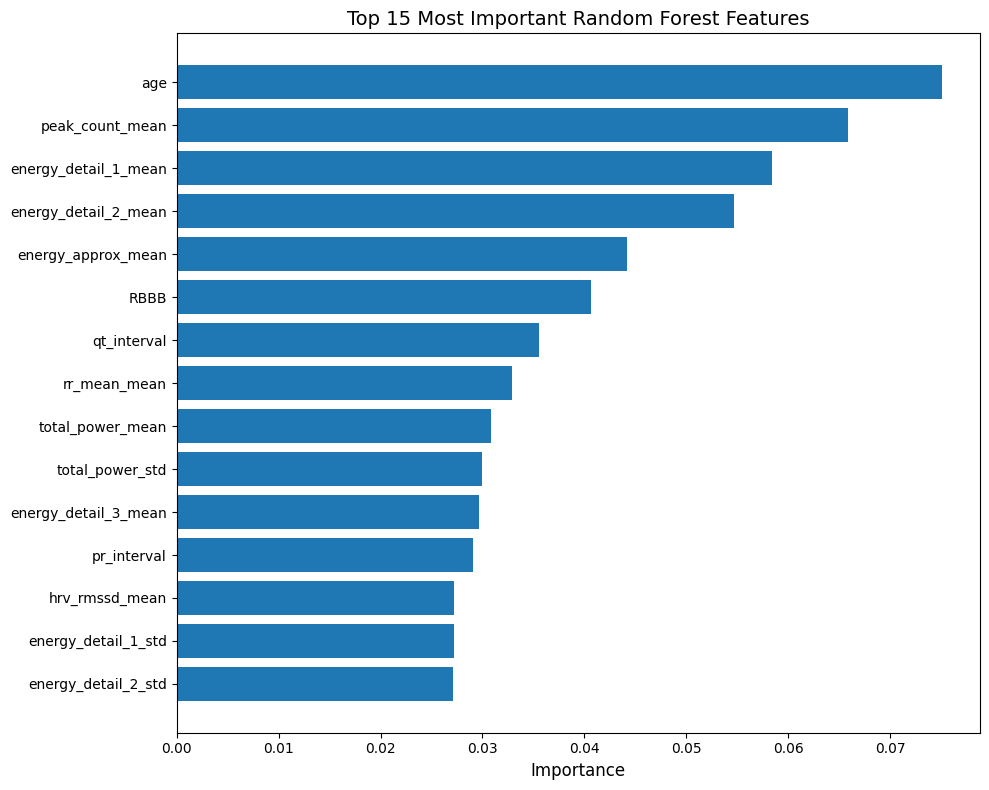

In [13]:
plt.figure(figsize=(10, 8))

top_features = feature_importance.head(15)

plt.barh(range(len(top_features)), top_features["Importance"])
plt.yticks(range(len(top_features)), top_features["Feature"])
plt.xlabel("Importance", fontsize=12)
plt.title("Top 15 Most Important Random Forest Features", fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()




  ## 11. Final Model Summary

In [14]:
summary_df = pd.DataFrame({
    "Dataset": [
        "Validation - default threshold 0.5",
        "Validation - selected threshold by F2",
        "Test - default threshold 0.5",
        "Test - selected threshold by F2"
    ],
    "Threshold": [
        0.5,
        best_threshold,
        0.5,
        best_threshold
    ],
    "ROC-AUC": [
        val_roc_auc,
        val_roc_auc,
        test_roc_auc,
        test_roc_auc
    ],
    "PR-AUC": [
        val_pr_auc,
        val_pr_auc,
        test_pr_auc,
        test_pr_auc
    ],
    "Balanced Accuracy": [
        val_balanced_acc_default,
        val_balanced_acc_selected,
        test_balanced_acc_default,
        test_balanced_acc_selected
    ],
    "F1-score": [
        val_f1_default,
        val_f1_selected,
        test_f1_default,
        test_f1_selected
    ],
    "F2-score": [
        val_f2_default,
        val_f2_selected,
        test_f2_default,
        test_f2_selected
    ],
    "Precision": [
        val_precision_default,
        val_precision_selected,
        test_precision_default,
        test_precision_selected
    ],
    "Recall": [
        val_recall_default,
        val_recall_selected,
        test_recall_default,
        test_recall_selected
    ]
})

print(summary_df.to_string(index=False))

print("\nBest hyperparameters selected by validation PR-AUC:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nSelected threshold by validation F2: {best_threshold:.4f}")

print("\nTop 10 hyperparameter combinations by validation PR-AUC:")
print(results_df[display_cols].head(10).to_string(index=False))


                              Dataset  Threshold  ROC-AUC   PR-AUC  Balanced Accuracy  F1-score  F2-score  Precision   Recall
   Validation - default threshold 0.5       0.50 0.824458 0.132260           0.500417  0.001779  0.001115   0.250000 0.000893
Validation - selected threshold by F2       0.05 0.824458 0.132260           0.669139  0.192027  0.279093   0.126340 0.400000
         Test - default threshold 0.5       0.50 0.815152 0.125015           0.499970  0.000000  0.000000   0.000000 0.000000
      Test - selected threshold by F2       0.05 0.815152 0.125015           0.660546  0.167327  0.253030   0.106952 0.384226

Best hyperparameters selected by validation PR-AUC:
  class_weight: balanced_subsample
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 700

Selected threshold by validation F2: 0.0500

Top 10 hyperparameter combinations by validation PR-AUC:
      class_weight max_depth max_features  min_samples_leaf  min_samples_sp

In [15]:
rf_predictions = pd.DataFrame({
    "exam_id": df.loc[X_test.index, "exam_id"] if "exam_id" in df.columns else X_test.index,
    "y_true": y_test.values,
    "y_prob_rf": y_test_prob_best
})

rf_predictions.to_csv("rf_test_predictions.csv", index=False)


 ## 12. Learning curves

In [16]:
train_sizes = [0.1, 0.25, 0.5, 0.75, 1.0]

learning_curve_results = []

for size in train_sizes:
    if size < 1.0:
        gss = GroupShuffleSplit(
            n_splits=1,
            train_size=size,
            random_state=42
        )

        subset_idx, _ = next(
            gss.split(
                X_train,
                y_train,
                groups=groups_train
            )
        )

        X_train_part = X_train.iloc[subset_idx].copy()
        y_train_part = y_train.iloc[subset_idx].copy()

    else:
        X_train_part = X_train.copy()
        y_train_part = y_train.copy()

    model = clone(best_model)
    model.fit(X_train_part, y_train_part)

    y_train_prob = model.predict_proba(X_train_part)[:, 1]
    y_val_prob = model.predict_proba(X_val)[:, 1]

    train_pr_auc = average_precision_score(y_train_part, y_train_prob)
    val_pr_auc = average_precision_score(y_val, y_val_prob)

    learning_curve_results.append({
        "train_fraction": size,
        "n_train_samples": len(X_train_part),
        "n_positive_train": int(y_train_part.sum()),
        "train_pr_auc": train_pr_auc,
        "val_pr_auc": val_pr_auc
    })

learning_curve_df = pd.DataFrame(learning_curve_results)

print(learning_curve_df)


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(5, 4))

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["train_pr_auc"],
    marker="o",
    label="Training PR-AUC"
)

plt.plot(
    learning_curve_df["train_fraction"],
    learning_curve_df["val_pr_auc"],
    marker="o",
    label="Validation PR-AUC"
)

plt.xlabel("Training set fraction")
plt.ylabel("PR-AUC")
plt.title("Learning curve for random forest")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

